# Aplicação de Multi-layer Perceptron à séries temporais variantes no tempo

Dataset
Qual o objetivo?
Quais são as técnicas para separação dos dados? (Validação cruzada)
Quais os possíveis problemas no treinamento;

Na arquitetura do Modelo, qual a técnica ultizada para a escolha dos hiperparâmetros.

Quais as métricas de validação usadas para avaliar o desempenho do modelo.

In [173]:
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from kfold import Kfold
from mlp_kfold import FFNeuralNetwork, Layer, Neuron

import requests
import pystac_client
from scipy.signal import savgol_filter
import matplotlib.dates as mdates

def get_ts(sample):
    ts_ = json.loads(sample['time_series'])
    return pd.DataFrame(ts_)

def plot_ts(data_df, selected_line, marker=True, smoothed=False, step=5):
    ts = pd.DataFrame(json.loads(data_df['time_series'][selected_line]))
    fig = plt.figure(figsize=(10, 4))
    smoothed_ = ' Smoothed' if smoothed else ''
    fig.suptitle(
        ("{cube} {label} [{lng:,.4f}, {lat:,.4f}]{smoothed_} WGS 84 EPSG:4326").format(
            cube=data_df['cube'][selected_line],
            label=data_df['label'][selected_line],
            lng=data_df['longitude'][selected_line],
            lat=data_df['latitude'][selected_line],
            smoothed_=smoothed_
        )
    )
    seaborn.set_theme(style="darkgrid")
    bands = [band for band in list(ts.keys()) if band != 'Index']
    marker_ = 'o' if marker else None
    for band in bands:
        seaborn.lineplot(
            data=ts,
            x="Index",
            y=band,
            label=band,
            markersize=8,
            marker=marker_,
            linestyle='-'
        )
    ax = plt.gca()
    xticks = range(0, len(ts["Index"]), step)
    ax.set_xticks(xticks)
    ax.set_xticklabels(
        ts["Index"].iloc[::step]
    )
    plt.xlabel(None)
    plt.ylabel(None)
    plt.legend()
    plt.tight_layout()
    plt.show()

# get bands description
service = pystac_client.Client.open("https://data.inpe.br/bdc/stac/v1/")
collection = service.get_collection('mod13q1-6.1').to_dict()
bands_description = collection['properties']['eo:bands']

# Recuperando a base de dados
samples = pd.read_csv('./samples/samples_mt_time_series.csv')

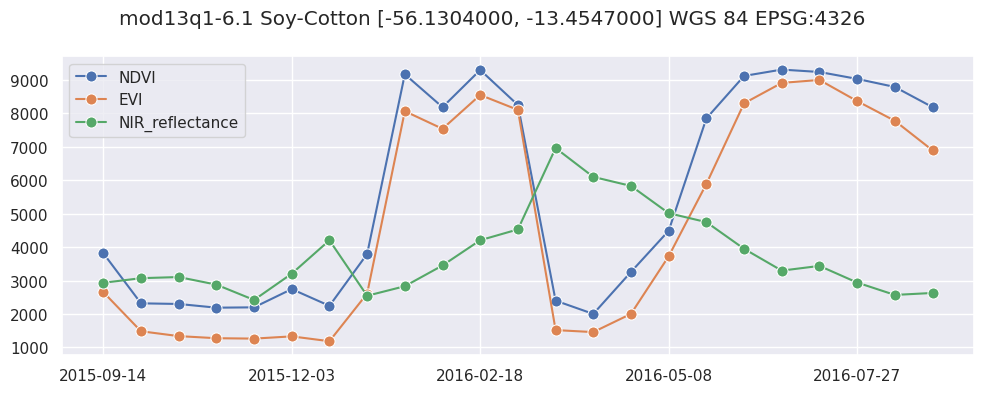

In [85]:
plot_ts(samples, random.randint(0, (len(samples) - 1)))

In [32]:
def get_band_description(band, bands_description):
    selected = {}
    for band_desc in bands_description:
        if band_desc['name'] == band:
            selected = band_desc
            break
    return selected
    
def normalize_ts(samples, line, bands_description):
    ts_ = pd.DataFrame(json.loads(samples['time_series'][line]))
    for column in ts_.columns:
        if column != "Index":
            band_desc = get_band_description(column, bands_description)
            scale = band_desc['scale']
            ts_[column] = ts_[column] * scale
    return ts_

def normalize_(samples, bands_description):
    samples_ = samples.copy()
    for row in range(0, len(samples_)):
        samples_.loc[row, 'time_series'] = json.dumps(normalize_ts(samples_, row, bands_description).to_dict(orient="list"))
    return samples_

samples_norm = normalize_(samples, bands_description)
samples_norm

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


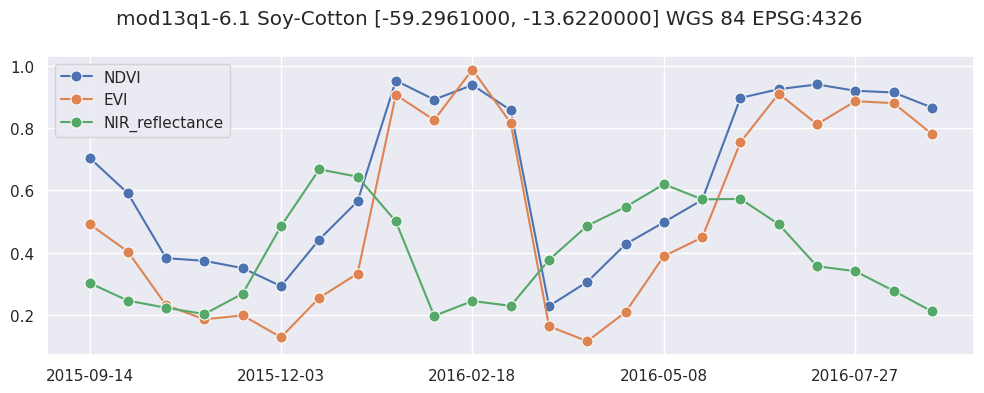

In [34]:
plot_ts(samples_norm, random.randint(0, (len(samples_norm) - 1)))

In [42]:
missing_value = 0

def _set_NaN(value):
    if value != missing_value:
        return value
    else:
        return None

def interpolate_ts(samples, line, bands_description):
    ts_ = pd.DataFrame(json.loads(samples['time_series'][line]))
    for column in ts_.columns:
        if column != "Index":
            band_desc = get_band_description(column, bands_description)
            scale = band_desc['scale']
            missing_value = band_desc['nodata'] * scale
            ts_[column] = ts_[column].apply(_set_NaN).interpolate(
                method = 'linear',
                limit_direction = 'forward',
                order = 2
            )
    return ts_

def interpolate_(samples, bands_description):
    samples_ = samples.copy()
    for row in range(0, len(samples_)):
        samples_.loc[row, 'time_series'] = json.dumps(interpolate_ts(samples_, row, bands_description).to_dict(orient="list"))
    return samples_

samples_inter = interpolate_(samples_norm, bands_description)
samples_inter

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


In [87]:
class SGolay:
    def __init__(self, window_size: int, polynomial_order: int, mode: str = "interp"):
        self.mode = mode
        if (window_size % 2) != 0:
            self.window_size = window_size
        else:
            raise Exception("Window size must be odd number!")
        if window_size > polynomial_order:
            self.polynomial_order = polynomial_order
        else:
            raise Exception("Window size must be higher than the polynomial order!")

    def apply(self, samples, line):
        ts_ = pd.DataFrame(json.loads(samples['time_series'][line]))
        for column in ts_.columns:
            if column != "Index":
                ts_[column] = savgol_filter(
                    ts_[column],
                    window_length=self.window_size,
                    polyorder=self.polynomial_order,
                    mode=self.mode
                )
        return ts_

def smooth_(samples):
    samples_ = samples.copy()
    for row in range(0, len(samples_)):
        sgolay = SGolay(7, 3)
        samples_.loc[row, 'time_series'] = json.dumps(sgolay.apply(samples_, row).to_dict(orient="list"))
    return samples_

samples_smoothed = smooth_(samples_inter)
samples_smoothed

,longitude,latitude,label,start_date,end_date,cube,time_series
0,-55.9643,-10.0621,Pasture,2005-09-14,2006-08-29,mod13q1-6.1,"{""Index"": [""2005-09-14"", ""2005-09-30"", ""2005-1..."
1,-54.5540,-10.3749,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
2,-52.4572,-10.9512,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
3,-52.1443,-13.9981,Pasture,2013-09-14,2014-08-29,mod13q1-6.1,"{""Index"": [""2013-09-14"", ""2013-09-30"", ""2013-1..."
4,-57.6907,-13.3382,Pasture,2015-09-14,2016-08-28,mod13q1-6.1,"{""Index"": [""2015-09-14"", ""2015-09-30"", ""2015-1..."
...,...,...,...,...,...,...,...
2110,-57.9273,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2111,-57.9254,-13.4254,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2112,-57.9254,-13.4235,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."
2113,-57.9254,-13.4216,Soy-Fallow,2006-09-14,2007-08-29,mod13q1-6.1,"{""Index"": [""2006-09-14"", ""2006-09-30"", ""2006-1..."


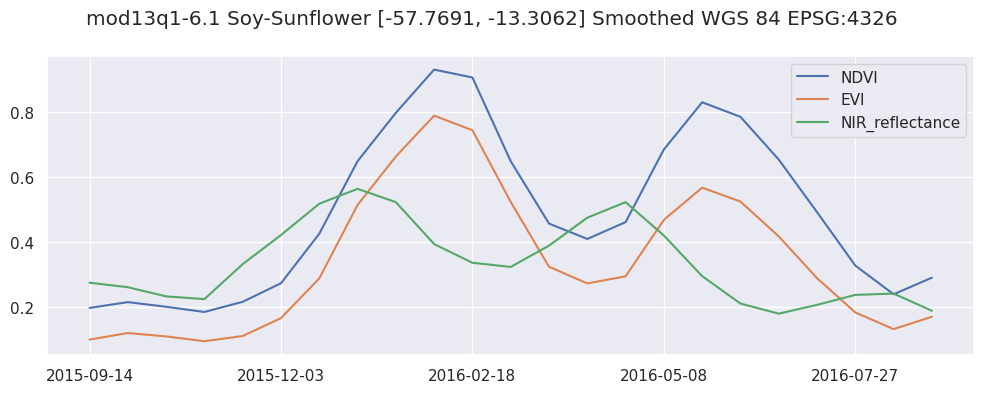

In [93]:
plot_ts(samples_smoothed, random.randint(0, (len(samples_inter) - 1)), marker = False, smoothed=True)

In [107]:
def count_ts(samples):
    samples_ = samples.copy()
    count = []
    for row in range(0, len(samples_)):
        count.append(len(json.loads(samples_['time_series'][0])['Index']))
    return count

set(count_ts(samples_smoothed))

{23}

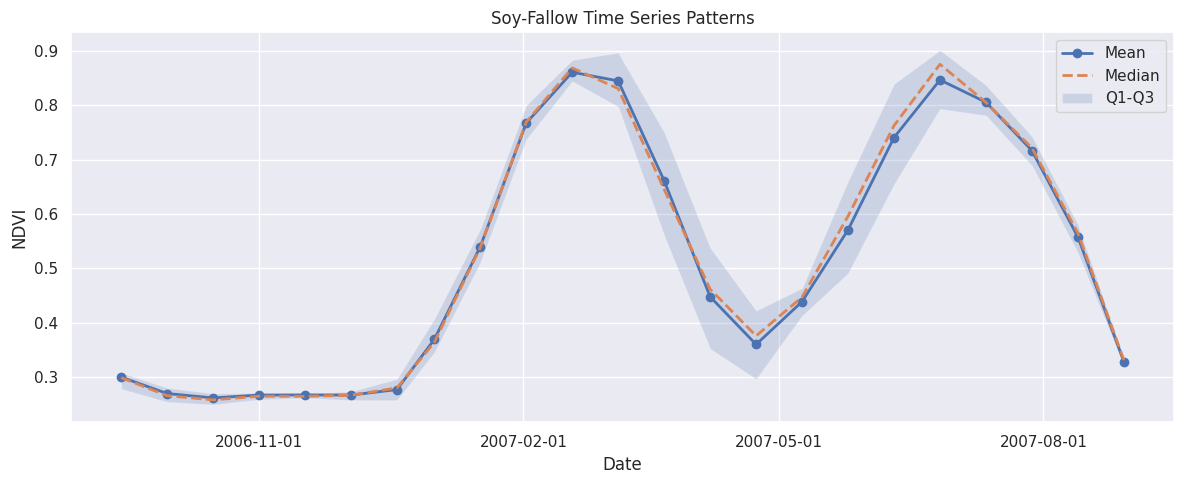

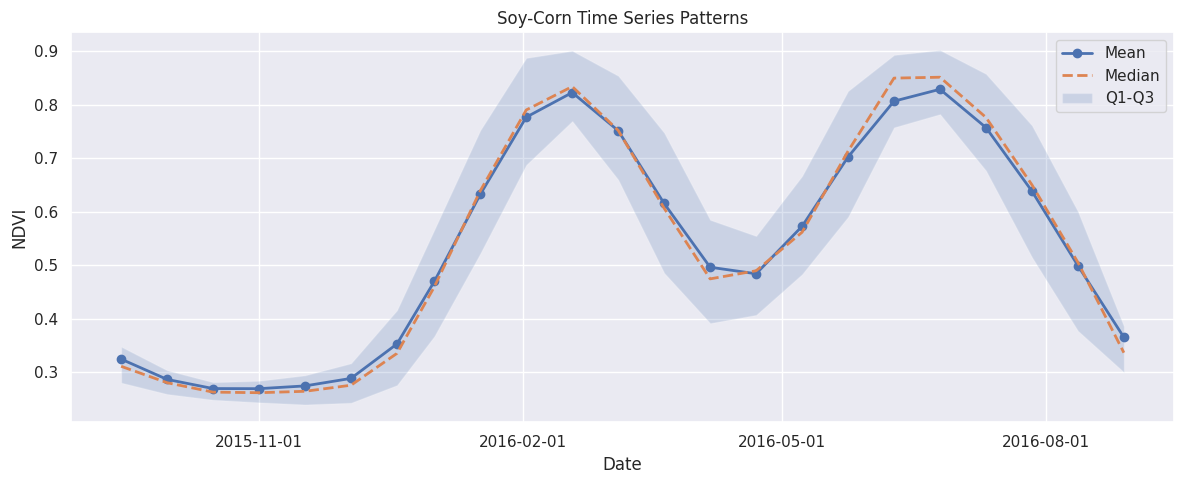

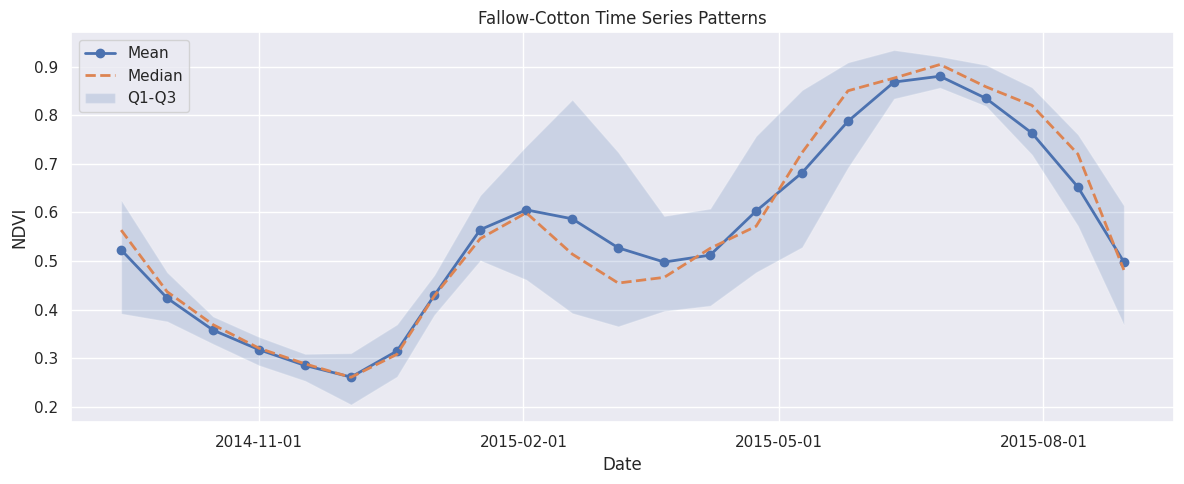

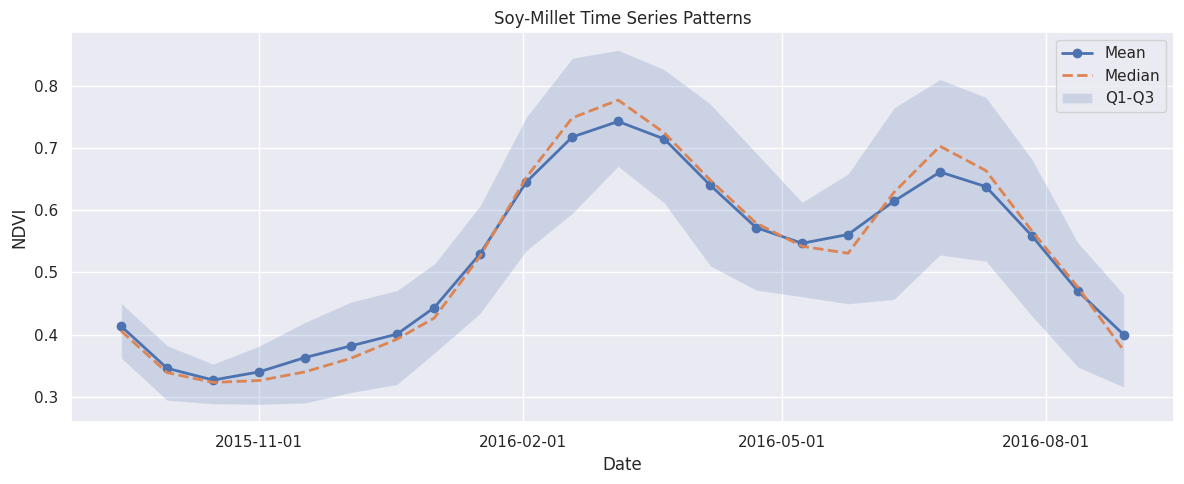

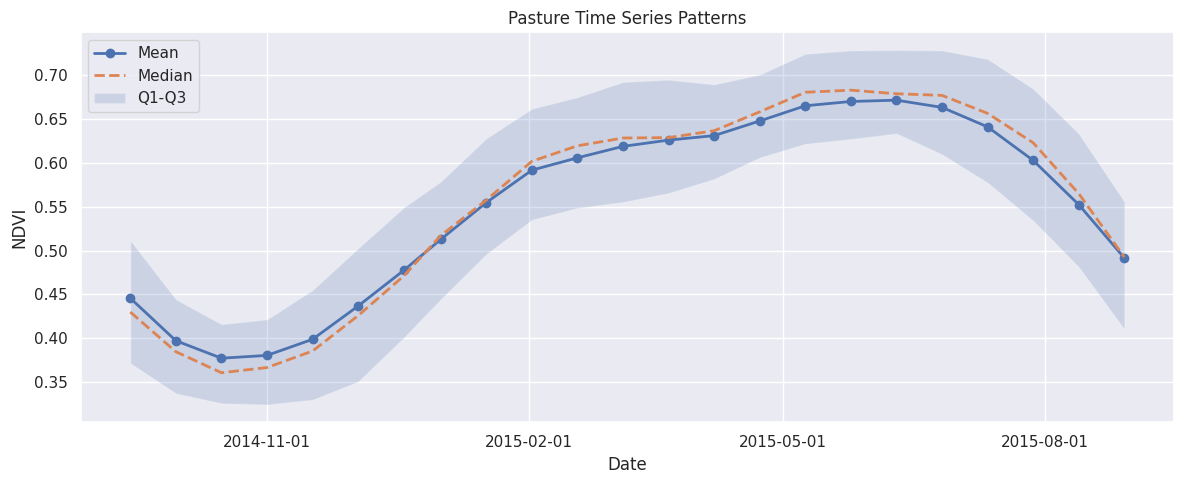

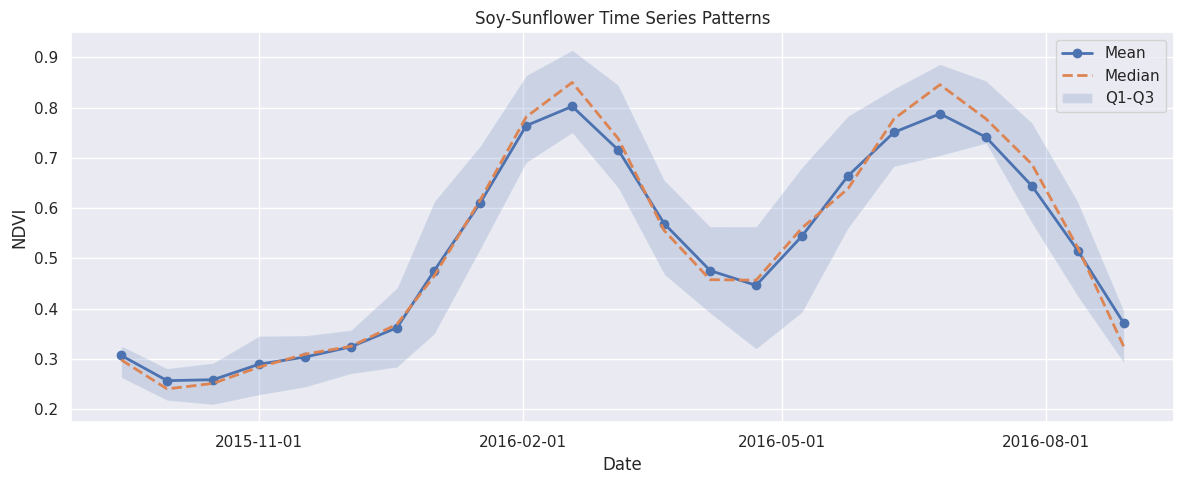

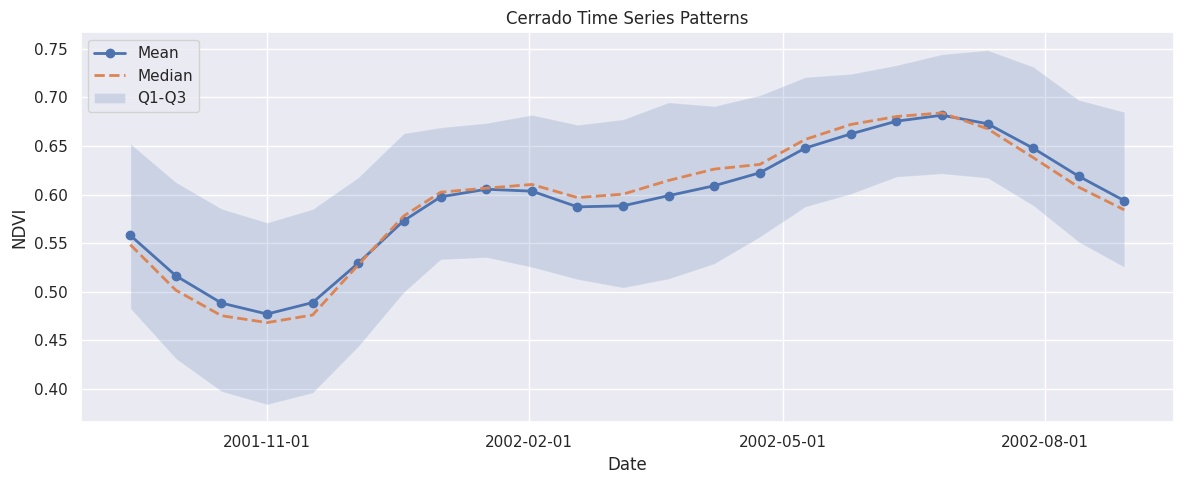

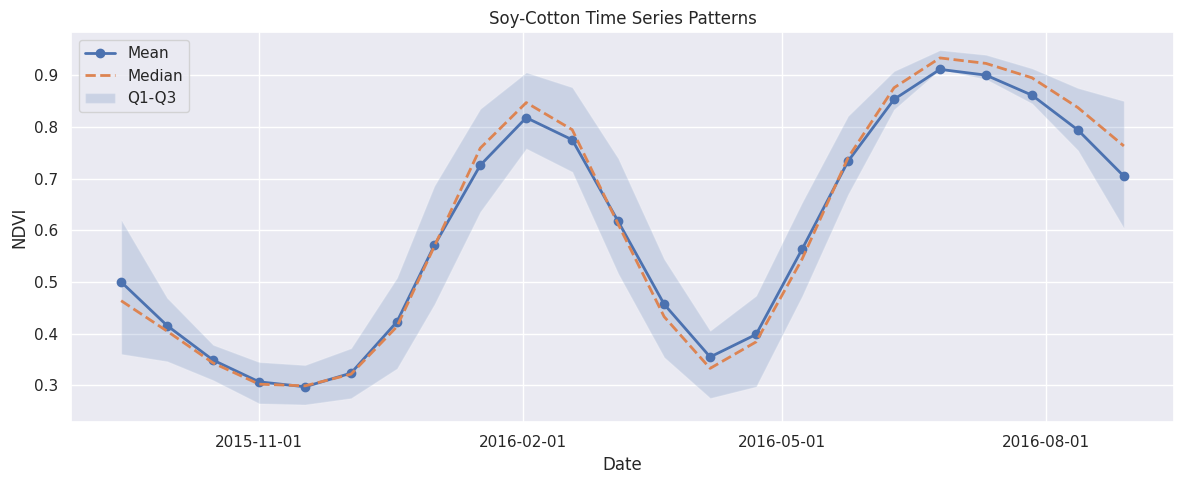

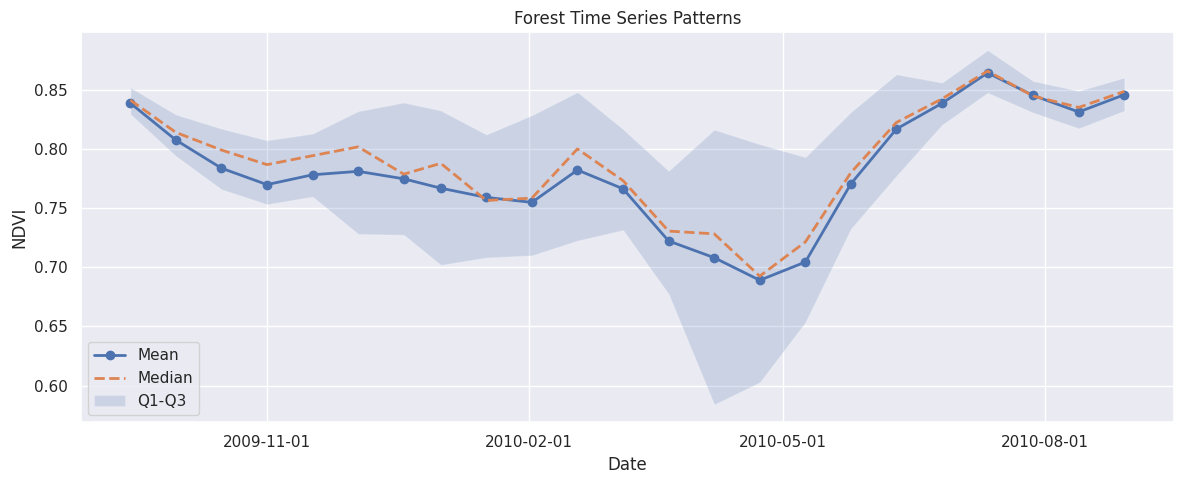

In [178]:
def plot_patterns(samples, band, step=3):

    labels = set(samples['label'])

    for label in labels:

        samples_label = (
            samples[samples['label'] == label]['time_series']
            .reset_index(drop=True)
        )

        all_values = []

        # Read all samples
        for row in range(len(samples_label)):

            df = pd.DataFrame(json.loads(samples_label[row]))

            # Keep only selected band
            values = df[band]

            all_values.append(values)

        # Create matrix:
        # rows = samples
        # cols = timesteps
        only_values = pd.concat(all_values, axis=1).T

        # Statistics
        mean_values = only_values.mean(axis=0)
        median_values = only_values.median(axis=0)

        q1 = only_values.quantile(0.25, axis=0)
        q3 = only_values.quantile(0.75, axis=0)

        # Dates
        indexes = pd.to_datetime(df["Index"])

        # Plot
        fig, ax = plt.subplots(figsize=(12, 5))

        # Mean curve
        ax.plot(
            indexes,
            mean_values,
            marker="o",
            linewidth=2,
            label="Mean"
        )

        # Median curve
        ax.plot(
            indexes,
            median_values,
            linestyle="--",
            linewidth=2,
            label="Median"
        )

        # Quartile interval
        ax.fill_between(
            indexes,
            q1,
            q3,
            alpha=0.2,
            label="Q1-Q3"
        )

        # Labels
        ax.set_title(f"{label} Time Series Patterns")
        ax.set_xlabel("Date")
        ax.set_ylabel(band)

        # Date spacing like your example
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=step))
        ax.xaxis.set_major_formatter(
            mdates.DateFormatter('%Y-%m-%d')
        )

        ax.legend()

        plt.tight_layout()
        plt.show()

plot_patterns(samples_smoothed, "NDVI")

9

In [189]:
set()

def getAllClasses():
    return pd.DataFrame({
        "class_name": np.unique(samples['label']),
        "index": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "color": ["#FF7D66", "#5480FF", "#BDBDBD", "#698891", "#487D5D", "#AB5B96", "#45A2BF", "#92D199", "#92A7D1"]
    })

def getClass(index=-1, label=''):
    classes = getAllClasses()
    if index > 0:
        result = classes[index == classes["index"]]
    if len(label):
        result = classes[label == classes["class_name"]]
    result = result.reset_index(drop = True)
    return result

classes = np.unique(samples['label'])

getAllClasses()

,class_name,index,color
0,Cerrado,1,#FF7D66
1,Fallow-Cotton,2,#5480FF
2,Forest,3,#BDBDBD
3,Pasture,4,#698891
4,Soy-Corn,5,#487D5D
5,Soy-Cotton,6,#AB5B96
6,Soy-Fallow,7,#45A2BF
7,Soy-Millet,8,#92D199
8,Soy-Sunflower,9,#92A7D1


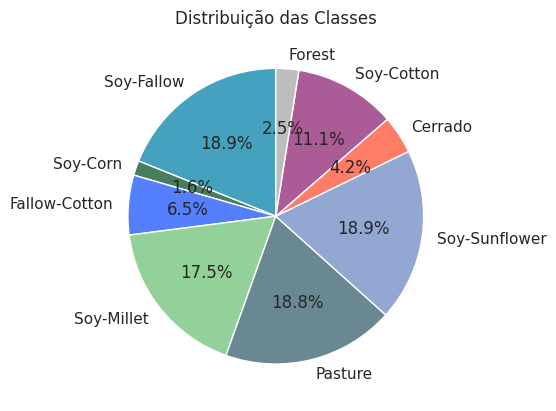

In [193]:
# Contar amostras por classe

def plot_distribution(samples):
    class_counts = pd.Series(list(samples['label'])).value_counts().sort_index()
    
    # Labels (nomes das classes)
    labels = [ str(getClass(label=label_)['class_name'][0]) for label_ in list(set(samples['label'])) ]
    
    colors = [ str(getClass(label=label_)['color'][0]) for label_ in list(set(samples['label'])) ]
    
    # Plotar gráfico de pizza
    plt.figure()
    plt.pie(class_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Distribuição das Classes')
    
    plt.show()

plot_distribution(samples=samples_smoothed)